## Plot the analyses in the database which show extreme deviations from SM expectations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import subprocess

In [3]:
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Palatino'
plt.rcParams['font.weight'] = '700'
plt.rcParams['axes.labelweight'] = '700'

# General publication aesthetics
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 12,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "axes.linewidth": 1.4,
})

In [5]:
import sys,os
sys.path.insert(0, os.path.expanduser("~/smodels"))
sys.path.insert(0, os.path.expanduser("~/protomodels"))
from smodels.base.physicsUnits import GeV
from smodels.experiment.databaseObj import Database
from smodels.experiment import datasetObj
from ptools.helpers import computePForDataSet, computeZFromP

In [6]:
database = Database("official")

In [7]:
tx = {}
tx["electroweakinos_onshell"]="TChiH,TChiChipmSlepStau,TChipChimSlepSnu,TChiHH,TChiWW,TChiWZ,TChipChimSlepSlep,TChipChimStauSnu,TChiZH,TChiWH,TChipChimgg,TChiZZ,TChiChipmStauStau,TChiChipmSlepSlep,TChiChipmSlepL,TChiChipmStauL"
tx["electroweakinos_offshell"]="TChiWZoff,TChiWWoff,TChiISR,TChiWISRll,TChiZISRll,TChiZISRqq"
tx["electroweakinos"] = tx['electroweakinos_onshell'].split(',') + tx['electroweakinos_offshell'].split(',')
print(tx["electroweakinos"])
print(tx["electroweakinos_onshell"], ',' ,tx["electroweakinos_offshell"])

['TChiH', 'TChiChipmSlepStau', 'TChipChimSlepSnu', 'TChiHH', 'TChiWW', 'TChiWZ', 'TChipChimSlepSlep', 'TChipChimStauSnu', 'TChiZH', 'TChiWH', 'TChipChimgg', 'TChiZZ', 'TChiChipmStauStau', 'TChiChipmSlepSlep', 'TChiChipmSlepL', 'TChiChipmStauL', 'TChiWZoff', 'TChiWWoff', 'TChiISR', 'TChiWISRll', 'TChiZISRll', 'TChiZISRqq']
TChiH,TChiChipmSlepStau,TChipChimSlepSnu,TChiHH,TChiWW,TChiWZ,TChipChimSlepSlep,TChipChimStauSnu,TChiZH,TChiWH,TChipChimgg,TChiZZ,TChiChipmStauStau,TChiChipmSlepSlep,TChiChipmSlepL,TChiChipmStauL , TChiWZoff,TChiWWoff,TChiISR,TChiWISRll,TChiZISRll,TChiZISRqq


In [24]:
#statistics
def getTotalResults(results):
    analyses = set()
    for res in results:
        if res.globalInfo.id not in analyses:
            analyses.add(res.globalInfo.id)
    analyses = list(analyses)
    print(analyses)
    return len(analyses)

results =  database.getExpResults(analysisIDs=['CMS-*'],dataTypes=['efficiencyMap'],txnames=tx["electroweakinos"])
num_results = getTotalResults(results)
print(f"Ewinos CMS {num_results}")

results =  database.getExpResults(analysisIDs=['ATLAS-*'],dataTypes=['efficiencyMap'],txnames=tx["electroweakinos"])
num_results = getTotalResults(results)
print(f"Ewinos ATLAS {num_results}")

results =  database.getExpResults(analysisIDs=['CMS-*'],dataTypes=['all'])
num_results = getTotalResults(results)
print(f"All CMS {num_results}")

results =  database.getExpResults(analysisIDs=['ATLAS-*'],dataTypes=['all'])
num_results = getTotalResults(results)
print(f"All ATLAS {num_results}")


['CMS-EXO-20-004', 'CMS-SUS-21-002', 'CMS-SUS-16-039-agg', 'CMS-SUS-20-004', 'CMS-SUS-16-048', 'CMS-SUS-13-012']
Ewinos CMS 6
['ATLAS-EXOT-2018-06', 'ATLAS-SUSY-2018-06', 'ATLAS-SUSY-2018-16', 'ATLAS-SUSY-2019-02', 'ATLAS-SUSY-2018-41', 'ATLAS-SUSY-2019-08', 'ATLAS-SUSY-2017-03', 'ATLAS-SUSY-2013-11', 'ATLAS-SUSY-2018-05-ewk', 'ATLAS-SUSY-2018-16-hino', 'ATLAS-SUSY-2013-12', 'ATLAS-SUSY-2019-09', 'ATLAS-SUSY-2016-24', 'ATLAS-SUSY-2018-32']
Ewinos ATLAS 14
['CMS-EXO-19-001', 'CMS-PAS-SUS-13-023', 'CMS-SUS-13-004', 'CMS-EXO-20-008', 'CMS-EXO-12-026', 'CMS-SUS-17-003', 'CMS-SUS-16-046', 'CMS-SUS-19-010', 'CMS-PAS-SUS-16-052', 'CMS-SUS-19-006-agg', 'CMS-SUS-16-037', 'CMS-SUS-16-009', 'CMS-SUS-16-034', 'CMS-SUS-16-036', 'CMS-SUS-18-002', 'CMS-SUS-18-007', 'CMS-SUS-19-011', 'CMS-SUS-13-013', 'CMS-SUS-16-039-agg', 'CMS-SUS-14-010', 'CMS-SUS-17-009', 'CMS-PAS-EXO-16-036', 'CMS-SUS-16-042', 'CMS-PAS-SUS-16-052-agg', 'CMS-SUS-16-039', 'CMS-SUS-17-010', 'CMS-SUS-13-011', 'CMS-SUS-20-004', 'CMS-SU

### Plot all analyses

In [ ]:
EMresults =  database.getExpResults(dataTypes=['efficiencyMap'])
sigMapMax = {}
sigMapMin = {}

for exp in EMresults:
    sigMax, sigMin = -np.infty, np.infty
    idsMax, idsMin = '',''
    for dataset in exp.datasets:
        pvalue = computePForDataSet(dataset)
        local_sig = computeZFromP(pvalue)
        dataId = dataset.dataInfo.dataId
        if local_sig > sigMax : 
            sigMax = local_sig    
            idsMax =  exp.globalInfo.id + ':' + dataId
        if local_sig < sigMin : 
            sigMin = local_sig
            idsMin =  exp.globalInfo.id + ':' + dataId

    sigMapMax[idsMax] = sigMax
    sigMapMin[idsMin] = sigMin

In [9]:
order_sigMapMax = dict(sorted(sigMapMax.items(), key=lambda item: item[1], reverse=True))
order_sigMapMin = dict(sorted(sigMapMin.items(), key=lambda item: item[1], reverse=True))

#order_sigMap = dict(sorted(sigMap.items(), key=lambda item: item[1], reverse=True))

#top_sig = {k:order_sigMap[k] for k in list(order_sigMap.keys())[:10]}
#bottom_sig = {k:order_sigMap[k] for k in list(order_sigMap.keys())[-10:]}

top_sig = {k:order_sigMapMax[k] for k in list(order_sigMapMax.keys())[:10]}
bottom_sig = {k:order_sigMapMin[k] for k in list(order_sigMapMin.keys())[-10:]}


for (ids, sig), (ids2,sig2) in zip(top_sig.items(), bottom_sig.items()):
    print(ids, ' : ', round(sig,2), ';\t', ids2, ' : ', round(sig2,2))

CMS-EXO-20-004:SR_2018_8  :  4.54 ;	 ATLAS-SUSY-2018-08:SRDFW  :  -1.86
ATLAS-SUSY-2018-42:SR1400_High_long  :  4.0 ;	 ATLAS-SUSY-2018-05-strong:SRHigh_Bin_1  :  -1.96
ATLAS-SUSY-2018-16-hino:SR_ewk_2l_med  :  3.27 ;	 ATLAS-SUSY-2013-11:WWc-SF  :  -1.96
ATLAS-SUSY-2018-16:SR_ewk_2l_ee_high_d  :  3.21 ;	 ATLAS-SUSY-2018-32:SRDF_0h_cuts  :  -1.97
ATLAS-SUSY-2017-03:SR3l_ISR  :  2.89 ;	 CMS-SUS-16-048:Ewkino_medMET_M_10to20  :  -2.01
ATLAS-SUSY-2019-09:SRlow_0Jd  :  2.59 ;	 CMS-EXO-20-004:SR_2016_18  :  -2.01
CMS-SUS-20-004:SR11  :  2.48 ;	 ATLAS-SUSY-2019-09:SRhigh_0Jf2  :  -2.23
ATLAS-EXOT-2018-06:EM10  :  2.45 ;	 CMS-SUS-19-006-agg:AR27  :  -2.39
CMS-PAS-SUS-16-052-agg:ar3  :  2.37 ;	 ATLAS-SUSY-2018-16:SR_ewk_2l_mm_high_c  :  -2.5
ATLAS-SUSY-2015-02:SR1  :  2.32 ;	 ATLAS-SUSY-2013-18:SR-1l-6j-B  :  -2.57


In [ ]:
#get the top and the bottom analyses

order_sigMap = dict(sorted(sigMap.items(), key=lambda item: item[1], reverse=True))

top_sig = {k:order_sigMap[k] for k in list(order_sigMap.keys())[:15]}
bottom_sig = {k:order_sigMap[k] for k in list(order_sigMap.keys())[-15:]}

#top_sig = {k:order_sigMapMax[k] for k in list(order_sigMapMax.keys())[:10]}
#bottom_sig = {k:order_sigMapMin[k] for k in list(order_sigMapMin.keys())[-10:]}


for (ids, sig), (ids2,sig2) in zip(top_sig.items(), bottom_sig.items()):
    print(ids, ' : ', round(sig,2), ';\t', ids2, ' : ', round(sig2,2))

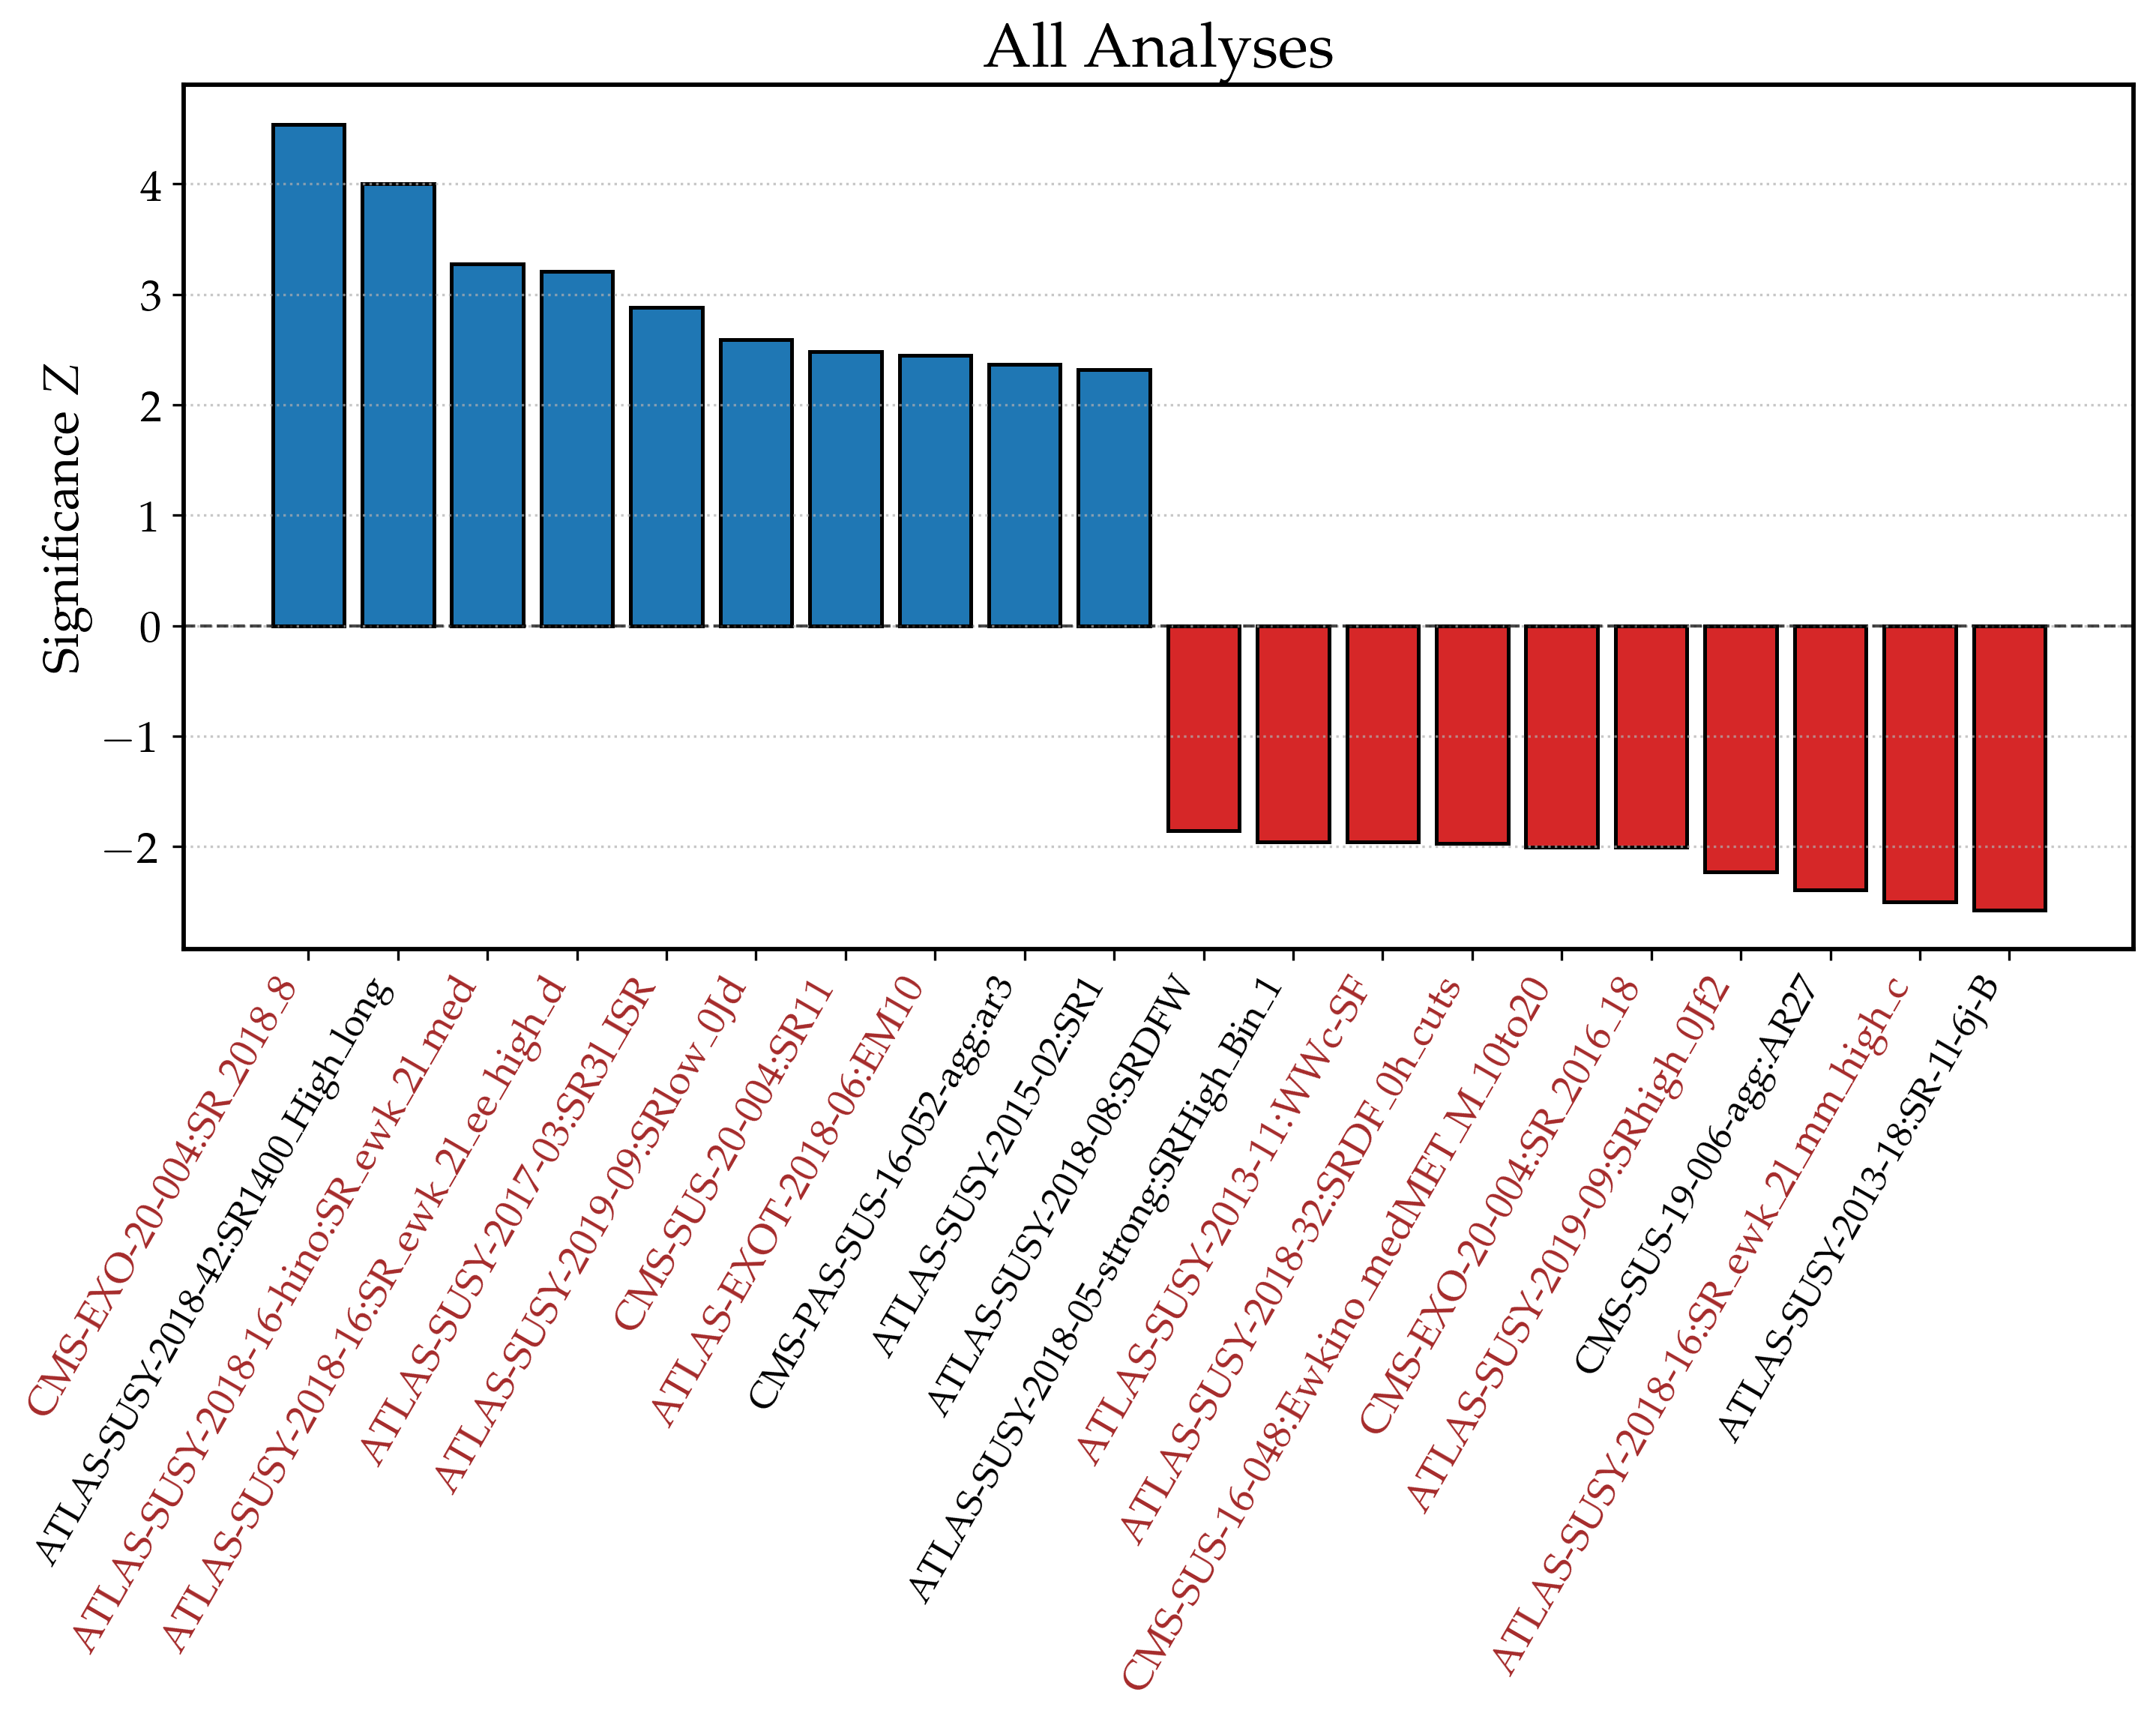

In [10]:
# Combine data
labels = list(top_sig.keys()) + list(bottom_sig.keys())
values = list(top_sig.values()) + list(bottom_sig.values())

colors = ["tab:blue"] * len(top_sig) + ["tab:red"] * len(bottom_sig)

plt.figure(figsize=(10, 8))
bars = plt.bar(labels, values, color=colors, edgecolor="black", linewidth=1.2)

plt.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)

plt.xticks(rotation=60, ha="right")
plt.yticks(fontsize=14)
plt.ylabel(r"Significance $Z$", fontsize=16)
plt.title("All Analyses", fontsize=20, fontweight="bold")

highlight_labels = {"CMS-EXO-20-004:SR_2018_8", "ATLAS-SUSY-2018-16-hino:SR_ewk_2l_med", "ATLAS-SUSY-2018-16:SR_ewk_2l_ee_high_d", "ATLAS-SUSY-2017-03:SR3l_ISR", "ATLAS-SUSY-2019-09:SRlow_0Jd", "CMS-SUS-20-004:SR11", "ATLAS-EXOT-2018-06:EM10", 
                    "ATLAS-SUSY-2018-16:SR_ewk_2l_mm_high_c",  "ATLAS-SUSY-2019-09:SRhigh_0Jf2",  "CMS-SUS-16-048:Ewkino_medMET_M_10to20", "CMS-EXO-20-004:SR_2016_18",  "ATLAS-SUSY-2018-32:SRDF_0h_cuts", "ATLAS-SUSY-2013-11:WWc-SF",}

ax = plt.gca()
for label in ax.get_xticklabels():
    text = label.get_text()
    #print(text)
    if text in highlight_labels:
        label.set_fontweight("bold")      # make bold
        label.set_color("brown")          # optional, ensure readable
        label.set_fontsize(13)            # optional, slightly larger

plt.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

### Plot only ewkinos+monojets

In [ ]:
EMresults =  database.getExpResults(dataTypes=['efficiencyMap'],txnames=tx["electroweakinos"])
sigMapMax = {}
sigMapMin = {}

for exp in EMresults:
    sigMax, sigMin = -np.infty, np.infty
    idsMax, idsMin = '',''
    for dataset in exp.datasets:
        pvalue = computePForDataSet(dataset)
        local_sig = computeZFromP(pvalue)
        dataId = dataset.dataInfo.dataId
        if local_sig > sigMax : 
            sigMax = local_sig    
            idsMax =  exp.globalInfo.id + ':' + dataId
        if local_sig < sigMin : 
            sigMin = local_sig
            idsMin =  exp.globalInfo.id + ':' + dataId

    sigMapMax[idsMax] = sigMax
    sigMapMin[idsMin] = sigMin

In [13]:
order_sigMapMax = dict(sorted(sigMapMax.items(), key=lambda item: item[1], reverse=True))
order_sigMapMin = dict(sorted(sigMapMin.items(), key=lambda item: item[1], reverse=True))

#order_sigMap = dict(sorted(sigMap.items(), key=lambda item: item[1], reverse=True))

#top_sig = {k:order_sigMap[k] for k in list(order_sigMap.keys())[:10]}
#bottom_sig = {k:order_sigMap[k] for k in list(order_sigMap.keys())[-10:]}

top_sig = {k:order_sigMapMax[k] for k in list(order_sigMapMax.keys())[:10]}
bottom_sig = {k:order_sigMapMin[k] for k in list(order_sigMapMin.keys())[-10:]}

top_sig['CMS-EXO-20-004:SR_2018_8'] = 4.54
for (ids, sig), (ids2,sig2) in zip(top_sig.items(), bottom_sig.items()):
    print(ids, ' : ', round(sig,2), ';\t', ids2, ' : ', round(sig2,2))

CMS-EXO-20-004:SR_2018_8  :  4.54 ;	 CMS-SUS-16-039-agg:AR11  :  -1.24
ATLAS-SUSY-2018-16-hino:SR_ewk_2l_med  :  3.36 ;	 ATLAS-SUSY-2017-03:SR2l_High  :  -1.31
ATLAS-SUSY-2018-16:SR_ewk_2l_ee_high_d  :  3.3 ;	 ATLAS-SUSY-2018-05-ewk:SRHigh8_2_cuts  :  -1.48
ATLAS-SUSY-2017-03:SR3l_ISR  :  2.9 ;	 CMS-SUS-21-002:W_SR5  :  -1.61
ATLAS-SUSY-2019-09:SRlow_0Jd  :  2.55 ;	 ATLAS-SUSY-2013-11:WWc-SF  :  -1.96
CMS-SUS-20-004:SR11  :  2.49 ;	 ATLAS-SUSY-2018-32:SRDF_0h_cuts  :  -1.99
ATLAS-EXOT-2018-06:EM10  :  2.45 ;	 CMS-EXO-20-004:SR_2016_18  :  -1.99
ATLAS-SUSY-2018-32:SRSF_1c_cuts  :  2.09 ;	 CMS-SUS-16-048:Ewkino_medMET_M_10to20  :  -2.0
ATLAS-SUSY-2016-24:WZ-1Jc  :  1.86 ;	 ATLAS-SUSY-2019-09:SRhigh_0Jf2  :  -2.22
CMS-SUS-21-002:WH_SR3  :  1.86 ;	 ATLAS-SUSY-2018-16:SR_ewk_2l_mm_high_c  :  -2.49


In [ ]:
#get the top and the bottom analyses

order_sigMap = dict(sorted(sigMap.items(), key=lambda item: item[1], reverse=True))

top_sig = {k:order_sigMap[k] for k in list(order_sigMap.keys())[:15]}
bottom_sig = {k:order_sigMap[k] for k in list(order_sigMap.keys())[-15:]}

#top_sig = {k:order_sigMapMax[k] for k in list(order_sigMapMax.keys())[:10]}
#bottom_sig = {k:order_sigMapMin[k] for k in list(order_sigMapMin.keys())[-10:]}


for (ids, sig), (ids2,sig2) in zip(top_sig.items(), bottom_sig.items()):
    print(ids, ' : ', round(sig,2), ';\t', ids2, ' : ', round(sig2,2))

In [ ]:
labels = list(top_sig.keys()) + list(bottom_sig.keys())
values = list(top_sig.values()) + list(bottom_sig.values())

plt.figure(figsize=(10,6))
plt.bar(range(len(labels)), values, color="steelblue")
plt.xticks(range(len(labels)), labels, rotation=60, ha="right")
plt.ylabel("Significance Z")
plt.title("SRs with highest and lowest Z")
plt.tight_layout()
plt.show()

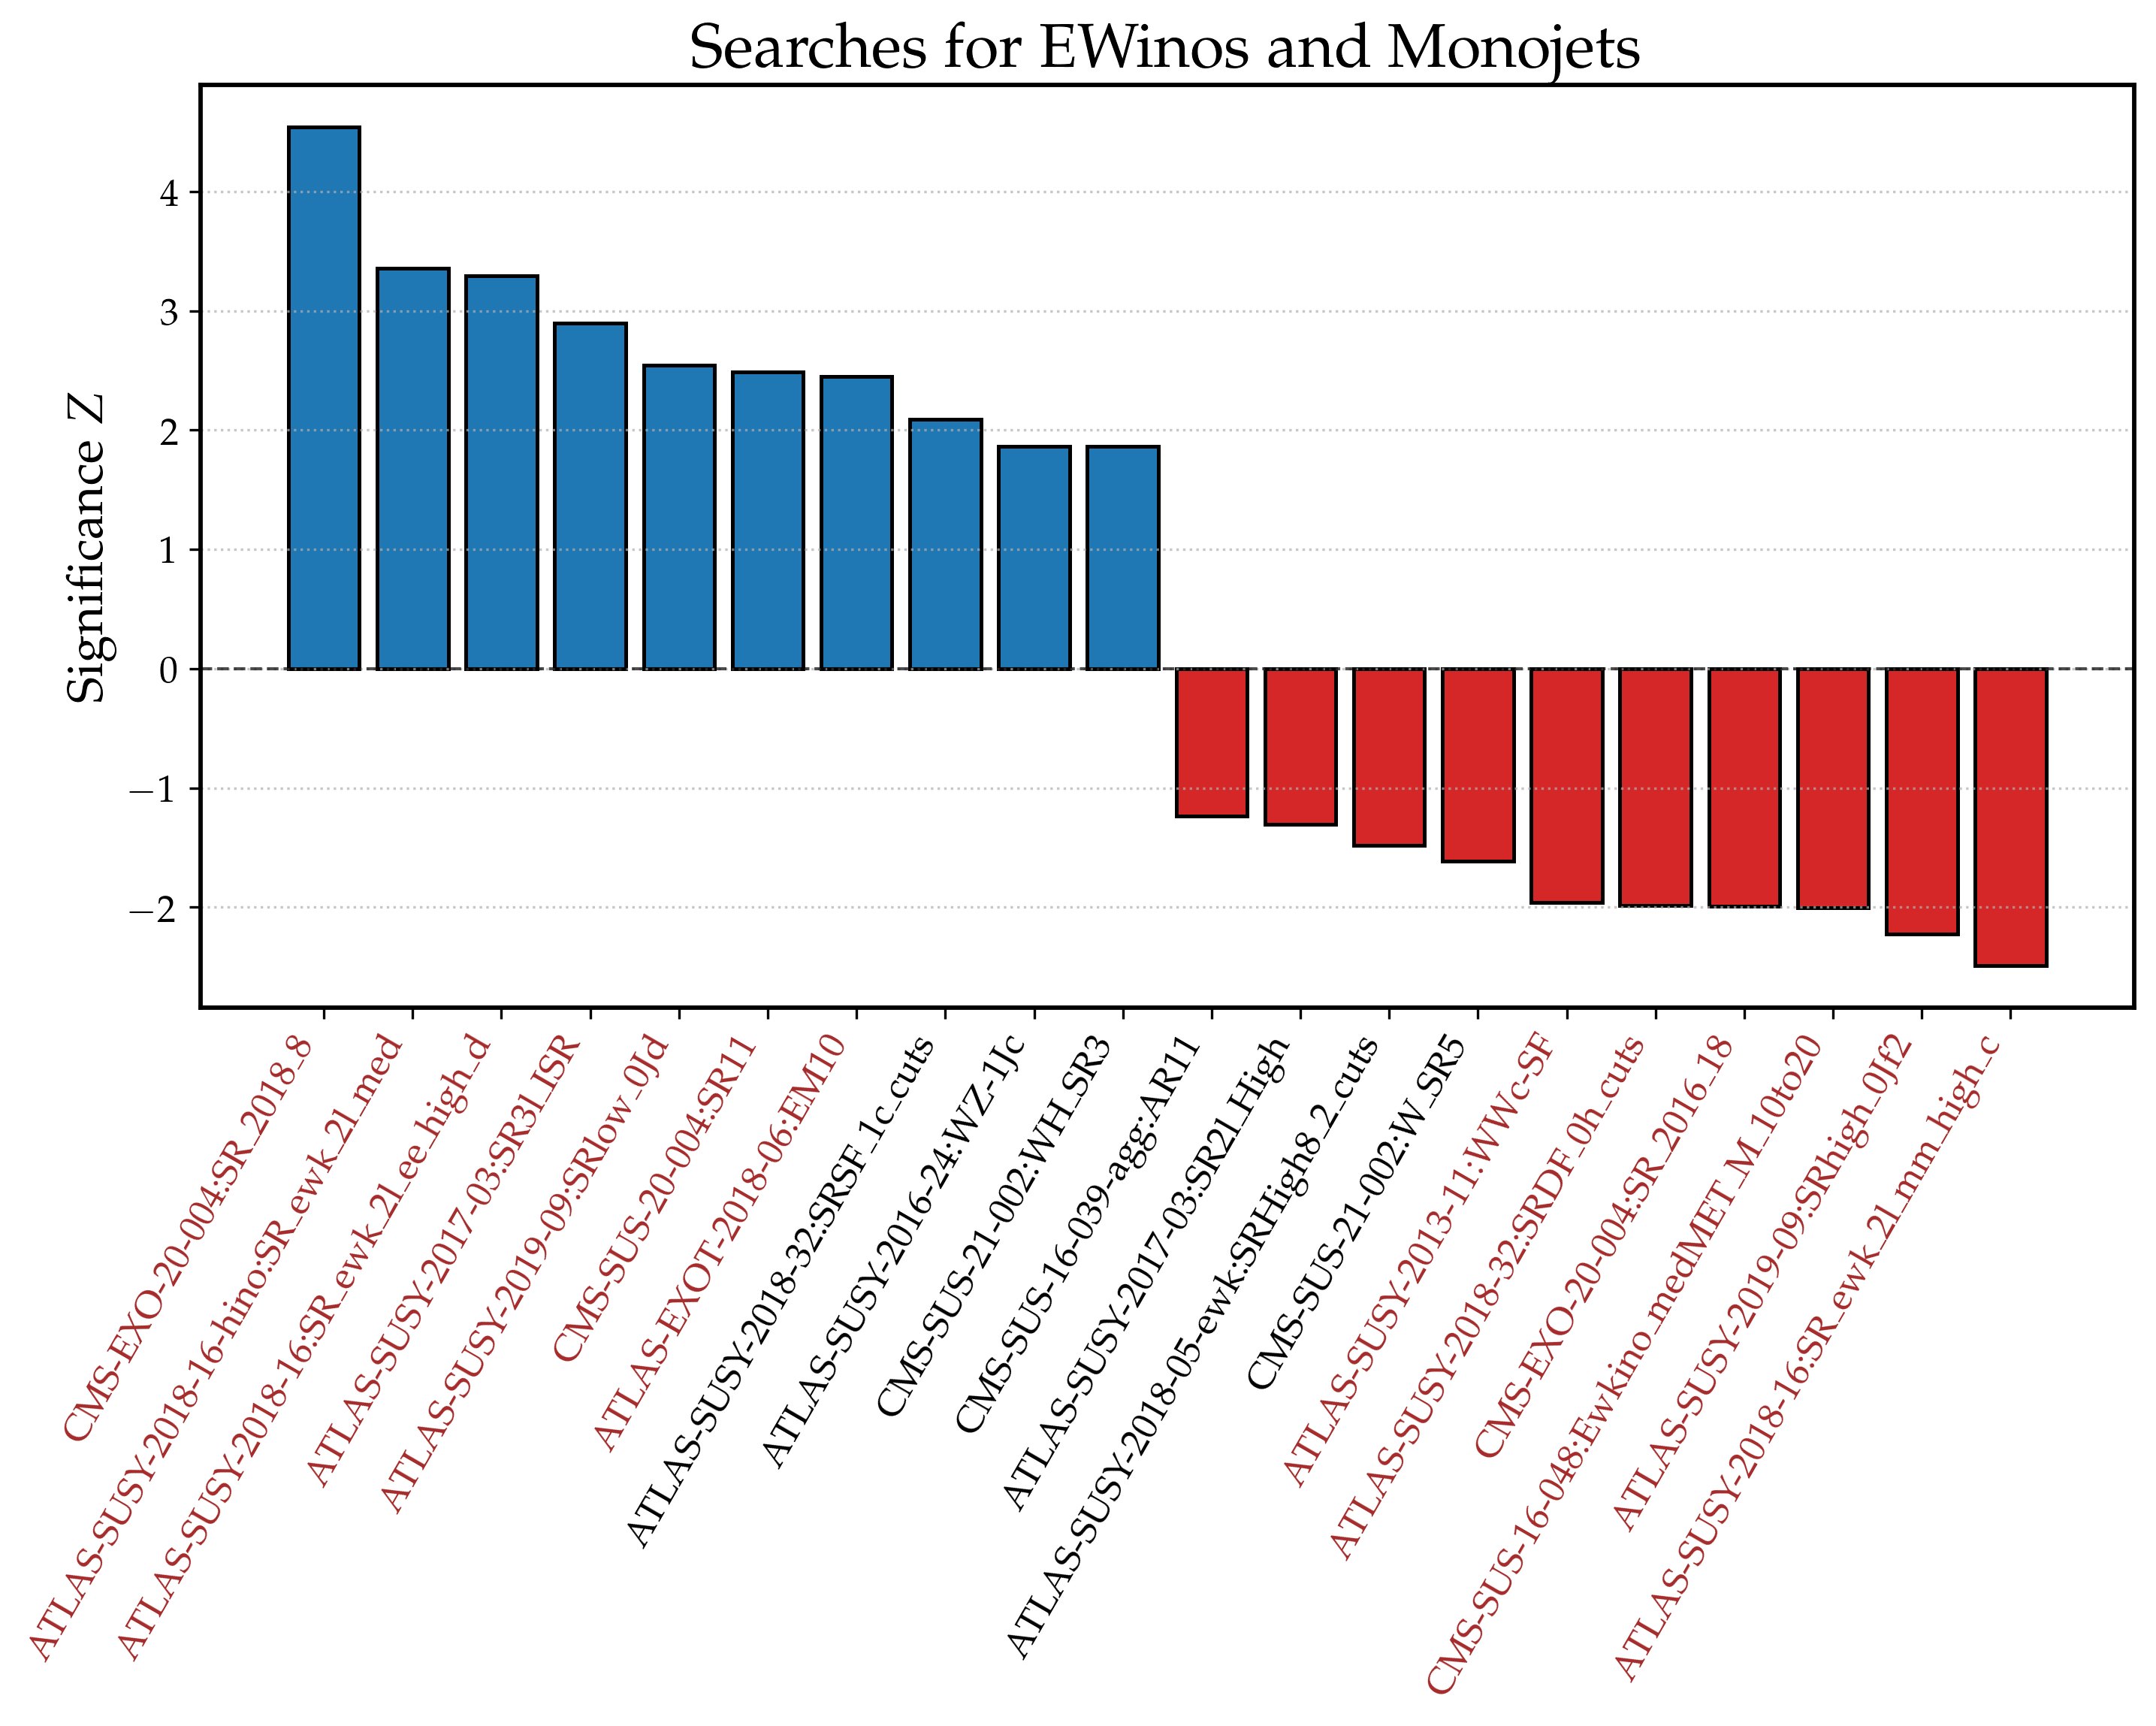

In [14]:
# Combine data
labels = list(top_sig.keys()) + list(bottom_sig.keys())
values = list(top_sig.values()) + list(bottom_sig.values())


colors = ["tab:blue"] * len(top_sig) + ["tab:red"] * len(bottom_sig)


plt.figure(figsize=(10, 8))
bars = plt.bar(labels, values, color=colors, edgecolor="black", linewidth=1.2)


plt.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)

plt.xticks(rotation=60, ha="right")
plt.ylabel(r"Significance $Z$", fontsize=16)
plt.yticks(fontsize=12)
plt.title("Searches for EWinos and Monojets", fontsize=20)

highlight_labels = {"CMS-EXO-20-004:SR_2018_8", "ATLAS-SUSY-2018-16-hino:SR_ewk_2l_med", "ATLAS-SUSY-2018-16:SR_ewk_2l_ee_high_d", "ATLAS-SUSY-2017-03:SR3l_ISR", "ATLAS-SUSY-2019-09:SRlow_0Jd", "CMS-SUS-20-004:SR11", "ATLAS-EXOT-2018-06:EM10", 
                    "ATLAS-SUSY-2018-16:SR_ewk_2l_mm_high_c",  "ATLAS-SUSY-2019-09:SRhigh_0Jf2",  "CMS-SUS-16-048:Ewkino_medMET_M_10to20", "CMS-EXO-20-004:SR_2016_18",  "ATLAS-SUSY-2018-32:SRDF_0h_cuts", "ATLAS-SUSY-2013-11:WWc-SF",}

ax = plt.gca()
for label in ax.get_xticklabels():
    text = label.get_text()
    #print(text)
    if text in highlight_labels:
        #label.set_fontweight("bold")      # make bold
        label.set_color("brown")          # optional, ensure readable
        label.set_fontsize(12)            # optional, slightly larger

plt.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7)

# Clean layout
plt.tight_layout()
plt.show()